<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/Tumor_mapping/tumour_mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")


Done extracting!


In [2]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm

root = "/content/extracted/archive"
train_dir = os.path.join(root, "Training")
test_dir  = os.path.join(root, "Testing")

img_size = 380
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

def crop_brain(img: Image.Image) -> Image.Image:
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return img

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img_np[y:y+h, x:x+w]
    return Image.fromarray(cropped)

from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

temp_model = timm.create_model("efficientnet_b4", pretrained=True)
config = resolve_data_config({}, model=temp_model)

train_transform = create_transform(**config)
test_transform  = create_transform(**config)

train_set = datasets.ImageFolder(train_dir, transform=train_transform)
test_set  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_set.classes
num_classes = len(class_names)

print("Classes:", class_names)

model = timm.create_model("efficientnet_b4", pretrained=True)

model.classifier = nn.Linear(model.classifier.in_features, num_classes)

model = model.to(device)

for param in model.parameters():
    param.requires_grad = False

for param in model.blocks[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

def train_one_epoch():
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate():
    model.eval()
    correct = 0
    total = 0

    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return correct / total

epochs = 10

for epoch in range(epochs):
    loss, acc = train_one_epoch()
    val_acc = evaluate()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Train Acc: {acc:.4f} | Test Acc: {val_acc:.4f}")

torch.save(model.state_dict(), "efficientnet_b4_tumor.pth")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Epoch 1/10 | Loss: 0.5075 | Train Acc: 0.8343 | Test Acc: 0.9031
Epoch 2/10 | Loss: 0.1193 | Train Acc: 0.9579 | Test Acc: 0.9287
Epoch 3/10 | Loss: 0.0455 | Train Acc: 0.9859 | Test Acc: 0.9506
Epoch 4/10 | Loss: 0.0312 | Train Acc: 0.9907 | Test Acc: 0.9463
Epoch 5/10 | Loss: 0.0142 | Train Acc: 0.9959 | Test Acc: 0.9481
Epoch 6/10 | Loss: 0.0144 | Train Acc: 0.9950 | Test Acc: 0.9463
Epoch 7/10 | Loss: 0.0122 | Train Acc: 0.9968 | Test Acc: 0.9419
Epoch 8/10 | Loss: 0.0100 | Train Acc: 0.9973 | Test Acc: 0.9387
Epoch 9/10 | Loss: 0.0104 | Train Acc: 0.9961 | Test Acc: 0.9481
Epoch 10/10 | Loss: 0.0044 | Train Acc: 0.9991 | Test Acc: 0.9450


In [4]:
pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=c683f8d8743bae0a37c5addc4dbb2a669dd155fca73b6bea54b3542be0349f3a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Running Grad-CAM++ on: /content/extracted/archive/Testing/meningioma/Te-me_5.jpg


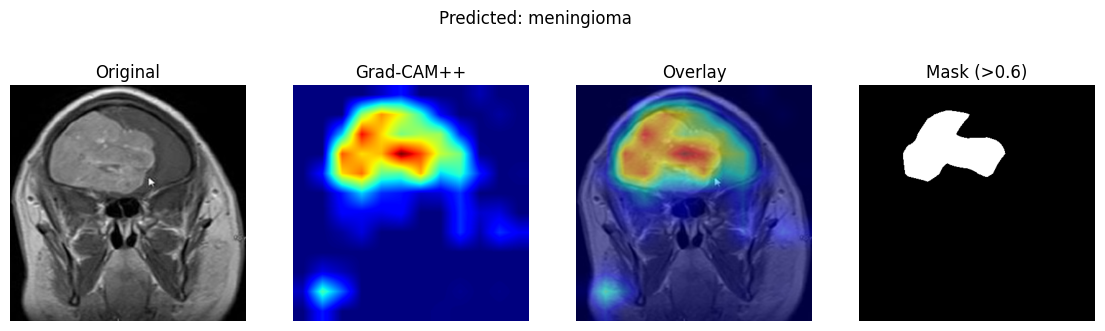

In [7]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

img_size = 380
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def crop_brain(img: Image.Image) -> Image.Image:
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return img

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img_np[y:y+h, x:x+w]
    return Image.fromarray(cropped)

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

import timm

model = timm.create_model("efficientnet_b4", pretrained=True)

num_classes = len(class_names)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)

model.load_state_dict(torch.load("efficientnet_b4_tumor.pth", map_location=device))
model = model.to(device)
model.eval()


target_layers = [model.blocks[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)


def apply_gradcam_pp(img_path, mask_threshold=0.6):

    pil = Image.open(img_path).convert("RGB")
    pil = crop_brain(pil)

    pil_resized = pil.resize((img_size, img_size))

    x = test_transform(pil_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        class_idx = outputs.argmax(1).item()

    grayscale_cam = cam(
        input_tensor=x,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0]

    grayscale_cam = cv2.resize(grayscale_cam, (img_size, img_size))

    original_np = np.array(pil_resized).astype(np.float32) / 255.0

    visualization = show_cam_on_image(original_np, grayscale_cam, use_rgb=True)

    mask = (grayscale_cam > mask_threshold).astype(np.uint8)

    plt.figure(figsize=(14,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(original_np)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Grad-CAM++")
    plt.imshow(grayscale_cam, cmap="jet")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Overlay")
    plt.imshow(visualization)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title(f"Mask (>{mask_threshold})")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.suptitle(f"Predicted: {class_names[class_idx]}")
    plt.show()


some_class = random.choice(class_names)
folder = os.path.join(test_dir, some_class)
example_img = os.path.join(folder, random.choice(os.listdir(folder)))

print("Running Grad-CAM++ on:", example_img)
apply_gradcam_pp(example_img, mask_threshold=0.6)